<a href="https://colab.research.google.com/github/elisecolin/Tutorials_Notebooks/blob/main/SimulationSAR_RMA_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAR stripmap simulation in a three-dimensional acquisition geometry

This notebook extends the previous stripmap omega–\(k\) / Range Migration Algorithm (RMA) simulation to a genuinely three-dimensional acquisition geometry. The radar follows a straight trajectory at constant altitude \(H\),

$$
\mathbf r_\mathrm{radar}(u)=(0,u,H),
$$

where \(u\) is the along-track synthetic-aperture coordinate. The scene remains a two-dimensional ground plane \(z=0\). A point scatterer is still specified by the triplet \((x_p,y_p,\rho_p)\), but its three-dimensional position is now

$$
\mathbf r_p=(X_c+x_p,\;y_p,\;0).
$$

The exact radar-to-target distance is consequently
$$
R_p(u)=
\sqrt{(X_c+x_p)^2+(y_p-u)^2+H^2}.
$$

This formulation is the appropriate preliminary step before introducing a response that is neither white nor isotropic. Once the look vector is three-dimensional, the scattering coefficient may later depend independently on frequency, incidence angle, azimuth aspect, and polarization.

A useful observation makes it possible to retain the two-dimensional RMA. Define the cross-track slant coordinate

$$
q_p=\sqrt{(X_c+x_p)^2+H^2}.
$$

Then

$$
R_p(u)=\sqrt{q_p^2+(y_p-u)^2},
$$

which has exactly the same mathematical form as the former two-dimensional model, provided the RMA reconstructs the image in \((q,y)\), not directly in ground coordinates \((X,y)\). The final image is therefore remapped from slant range \(q\) to ground range

$$
X=\sqrt{q^2-H^2}.
$$


## 1. Imports and numerical utilities


In [91]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional
from scipy.interpolate import interp1d


def next_even_integer(x: float) -> int:
    """Return the smallest even integer greater than or equal to x."""
    n = int(np.ceil(x))
    return n if n % 2 == 0 else n + 1


## 2. Acquisition parameters and three-dimensional geometry

The coordinate system is chosen as follows:

- $X$: ground-range coordinate, normal to the flight track;
- $Y$: azimuth or along-track coordinate;
- $Z$: vertical coordinate;
- the radar flies along $Y$ at $X=0$ and $Z=H$;
- the ground is the plane $Z=0$;
- the scene center is $(X_c,0,0)$.

The central slant range is

$$
R_c=\sqrt{X_c^2+H^2}.
$$

The central incidence angle, measured from the vertical ground normal, is

$$
\theta_c=\arctan\left(\frac{X_c}{H}\right).
$$

The nominal slant-range resolution remains \(c/(2B)\). Its ground-range projection near the scene center is approximately

$$
\Delta X \simeq \frac{c}{2B\sin\theta_c}.
$$


In [92]:
@dataclass
class SARParams:
    """Physical and numerical parameters for a monostatic stripmap SAR."""

    c: float = 3e8

    fc: float = 9.6e9
    B: float = 150e6
    Tp: float = 5e-6

    # Ground geometry.
    Xc: float = 3_000.0
    H: float = 1_000.0
    X0: float = 100.0
    Y0: float = 100.0

    azimuth_resolution: float = 1.0
    synthetic_aperture_length: Optional[float] = None

    range_oversampling: float = 2.0
    aperture_oversampling: float = 1.25
    time_guard: float = 0.10

    n: Optional[int] = None
    m: Optional[int] = None
    du: Optional[float] = None

    def ground_to_slant(self, X):
        """Map absolute ground range X to cross-track slant coordinate q."""
        X = np.asarray(X, dtype=float)
        return np.sqrt(X**2 + self.H**2)

    def slant_to_ground(self, q):
        """Map cross-track slant coordinate q to positive ground range X."""
        q = np.asarray(q, dtype=float)
        if np.any(q < self.H):
            raise ValueError("The slant coordinate q must satisfy q >= H.")
        return np.sqrt(np.maximum(q**2 - self.H**2, 0.0))

    def radar_position(self, u):
        """Return radar positions [X,Y,Z] for aperture coordinates u."""
        u = np.asarray(u, dtype=float)
        return np.stack(
            [np.zeros_like(u), u, np.full_like(u, self.H)],
            axis=-1,
        )

    def target_positions(self, x_targets, y_targets):
        """Return ground-target positions [X,Y,Z] from relative (x,y)."""
        x_targets = np.asarray(x_targets, dtype=float)
        y_targets = np.asarray(y_targets, dtype=float)
        if x_targets.shape != y_targets.shape:
            raise ValueError("x_targets and y_targets must have identical shapes.")
        return np.stack(
            [
                self.Xc + x_targets,
                y_targets,
                np.zeros_like(x_targets),
            ],
            axis=-1,
        )

    def build_axes(self) -> dict:
        """Build the time, aperture, frequency, and wavenumber grids."""
        pi2 = 2.0 * np.pi

        if self.B <= 0:
            raise ValueError("The chirp bandwidth B must be strictly positive.")
        if self.fc <= self.B / 2.0:
            raise ValueError("The carrier frequency fc must be greater than B/2.")
        if self.Xc <= self.X0:
            raise ValueError("Xc must be greater than X0.")
        if self.H <= 0:
            raise ValueError("The radar altitude H must be strictly positive.")

        f_min = self.fc - self.B / 2.0
        f_max = self.fc + self.B / 2.0

        lambda_c = self.c / self.fc
        lambda_min = self.c / f_max
        lambda_max = self.c / f_min

        wc = pi2 * self.fc
        k_c = pi2 * self.fc / self.c
        k_min = pi2 * f_min / self.c
        k_max = pi2 * f_max / self.c

        # Baseband chirp:
        # p(tau) = exp(j[-pi B tau + alpha tau^2]), 0 <= tau <= Tp.
        alpha = np.pi * self.B / self.Tp

        slant_range_resolution = self.c / (2.0 * self.B)

        Rc = float(self.ground_to_slant(self.Xc))
        q_near = float(self.ground_to_slant(self.Xc - self.X0))
        q_far = float(self.ground_to_slant(self.Xc + self.X0))
        q_half_extent = max(Rc - q_near, q_far - Rc)

        incidence_angle_center = np.arctan2(self.Xc, self.H)
        ground_range_resolution_center = (
            slant_range_resolution / np.sin(incidence_angle_center)
        )

        if self.synthetic_aperture_length is None:
            Lsa = lambda_c * Rc / (2.0 * self.azimuth_resolution)
        else:
            Lsa = float(self.synthetic_aperture_length)

        if Lsa <= 0:
            raise ValueError("The synthetic aperture length must be positive.")

        aperture_half_length = Lsa / 2.0

        # Maximum along-track spatial frequency over the nominal scene.
        max_cross_offset = self.Y0 + aperture_half_length
        sin_squint_max = max_cross_offset / np.sqrt(
            q_near**2 + max_cross_offset**2
        )
        ku_max_signal = 2.0 * k_max * sin_squint_max
        du_nyquist = np.pi / ku_max_signal

        du = (
            du_nyquist / self.aperture_oversampling
            if self.du is None
            else float(self.du)
        )

        if du <= 0:
            raise ValueError("The aperture sampling step du must be positive.")

        if self.m is None:
            m = next_even_integer(Lsa / du)
        else:
            m = int(self.m)
            if m % 2 != 0:
                raise ValueError("m must be even.")

        Lsa_effective = m * du

        u = (np.arange(m) - m / 2.0) * du
        dku = pi2 / (m * du)
        ku = (np.arange(m) - m / 2.0) * dku

        # Fast-time limits over the complete ground rectangle and aperture.
        Rmin = q_near
        Rmax = np.sqrt(q_far**2 + max_cross_offset**2)

        Ts = 2.0 * Rmin / self.c
        Tf = 2.0 * Rmax / self.c + self.Tp

        T = Tf - Ts
        Ts = Ts - self.time_guard * T
        Tf = Tf + self.time_guard * T
        T = Tf - Ts

        fs_fast_time = self.range_oversampling * self.B
        dt = 1.0 / fs_fast_time

        if self.n is None:
            n = next_even_integer(T / dt)
        else:
            n = int(self.n)
            if n % 2 != 0:
                raise ValueError("n must be even.")

        t = Ts + np.arange(n) * dt

        f_base = np.fft.fftshift(np.fft.fftfreq(n, d=dt))
        f = self.fc + f_base
        w = pi2 * f
        k = w / self.c

        Ik = np.where(np.abs(f_base) <= self.B / 2.0)[0]

        return {
            "pi2": pi2,
            "c": self.c,
            "fc": self.fc,
            "B": self.B,
            "Tp": self.Tp,
            "wc": wc,
            "alpha": alpha,
            "slant_range_resolution": slant_range_resolution,
            "ground_range_resolution_center": ground_range_resolution_center,
            "incidence_angle_center": incidence_angle_center,
            "f_min": f_min,
            "f_max": f_max,
            "lambda_c": lambda_c,
            "lambda_min": lambda_min,
            "lambda_max": lambda_max,
            "k_c": k_c,
            "k_min": k_min,
            "k_max": k_max,
            "Rc": Rc,
            "q_near": q_near,
            "q_far": q_far,
            "q_half_extent": q_half_extent,
            "synthetic_aperture_length": Lsa,
            "synthetic_aperture_length_effective": Lsa_effective,
            "aperture_half_length": aperture_half_length,
            "du": du,
            "du_nyquist": du_nyquist,
            "m": m,
            "u": u,
            "dku": dku,
            "ku": ku,
            "ku_max_signal": ku_max_signal,
            "Rmin": Rmin,
            "Rmax": Rmax,
            "Ts": Ts,
            "Tf": Tf,
            "T": T,
            "dt": dt,
            "fs_fast_time": fs_fast_time,
            "n": n,
            "t": t,
            "f_base": f_base,
            "f": f,
            "w": w,
            "k": k,
            "Ik": Ik,
        }


def print_sar_summary(params: SARParams) -> None:
    """Print the main physical, geometric, and numerical quantities."""
    axes = params.build_axes()

    print("=== Radar ===")
    print(f"Carrier frequency fc             : {axes['fc'] / 1e9:.3f} GHz")
    print(f"Bandwidth B                      : {axes['B'] / 1e6:.3f} MHz")
    print(f"Pulse duration Tp                : {axes['Tp'] * 1e6:.3f} µs")
    print(f"Carrier wavelength lambda_c      : {axes['lambda_c']:.4f} m")
    print()

    print("=== Three-dimensional geometry ===")
    print(f"Radar altitude H                 : {params.H:.1f} m")
    print(f"Scene-center ground range Xc     : {params.Xc:.1f} m")
    print(f"Scene-center slant range Rc      : {axes['Rc']:.3f} m")
    print(
        f"Central incidence angle          : "
        f"{np.degrees(axes['incidence_angle_center']):.3f} deg"
    )
    print(
        f"Ground-range interval            : "
        f"[{params.Xc - params.X0:.1f}, {params.Xc + params.X0:.1f}] m"
    )
    print(f"Azimuth interval                 : [{-params.Y0:.1f}, {params.Y0:.1f}] m")
    print()

    print("=== Nominal resolutions ===")
    print(
        f"Slant-range resolution c/(2B)    : "
        f"{axes['slant_range_resolution']:.3f} m"
    )
    print(
        f"Ground-range resolution at center: "
        f"{axes['ground_range_resolution_center']:.3f} m"
    )
    print(f"Azimuth resolution target        : {params.azimuth_resolution:.3f} m")
    print()

    print("=== Synthetic aperture ===")
    print(f"Target aperture length           : {axes['synthetic_aperture_length']:.3f} m")
    print(f"Effective aperture length        : {axes['synthetic_aperture_length_effective']:.3f} m")
    print(f"Used aperture step du            : {axes['du']:.4f} m")
    print(f"Number of aperture samples m     : {axes['m']}")
    print()

    print("=== Fast-time sampling ===")
    print(f"Fast-time step dt                : {axes['dt'] * 1e9:.3f} ns")
    print(f"Sampling frequency               : {axes['fs_fast_time'] / 1e6:.3f} MHz")
    print(f"Number of fast-time samples n    : {axes['n']}")
    print(f"Fast-time window                 : {axes['T'] * 1e6:.3f} µs")
    print(f"Useful chirp bins                : {len(axes['Ik'])} / {axes['n']}")


params = SARParams(
    fc=9.6e9,
    B=150e6,
    Tp=5e-6,
    Xc=3000.0,
    H=1000.0,
    X0=100.0,
    Y0=100.0,
    azimuth_resolution=1.0,
)

print_sar_summary(params)


=== Radar ===
Carrier frequency fc             : 9.600 GHz
Bandwidth B                      : 150.000 MHz
Pulse duration Tp                : 5.000 µs
Carrier wavelength lambda_c      : 0.0312 m

=== Three-dimensional geometry ===
Radar altitude H                 : 1000.0 m
Scene-center ground range Xc     : 3000.0 m
Scene-center slant range Rc      : 3162.278 m
Central incidence angle          : 71.565 deg
Ground-range interval            : [2900.0, 3100.0] m
Azimuth interval                 : [-100.0, 100.0] m

=== Nominal resolutions ===
Slant-range resolution c/(2B)    : 1.000 m
Ground-range resolution at center: 1.054 m
Azimuth resolution target        : 1.000 m

=== Synthetic aperture ===
Target aperture length           : 49.411 m
Effective aperture length        : 49.467 m
Used aperture step du            : 0.1527 m
Number of aperture samples m     : 324

=== Fast-time sampling ===
Fast-time step dt                : 3.333 ns
Sampling frequency               : 300.000 MHz
Number 

## 3. Ground scatterers and look geometry

The scatterers continue to be declared only through their ground coordinates \((x_p,y_p)\), relative to the scene center in range and absolute in azimuth. Their altitude is fixed internally to zero.

For a target and an aperture position, the unit propagation vector from the radar to the target is

$$
\widehat{\mathbf k}_{\mathrm{inc}}(u)
=
\frac{\mathbf r_p-\mathbf r_\mathrm{radar}(u)}
{\|\mathbf r_p-\mathbf r_\mathrm{radar}(u)\|}.
$$

This vector will become the natural argument of a future anisotropic scattering law. Its vertical component controls incidence, while its horizontal projection controls the azimuthal aspect.


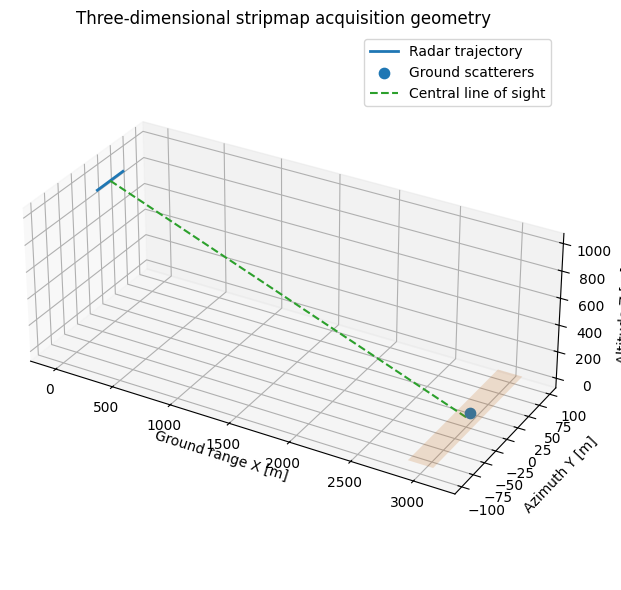

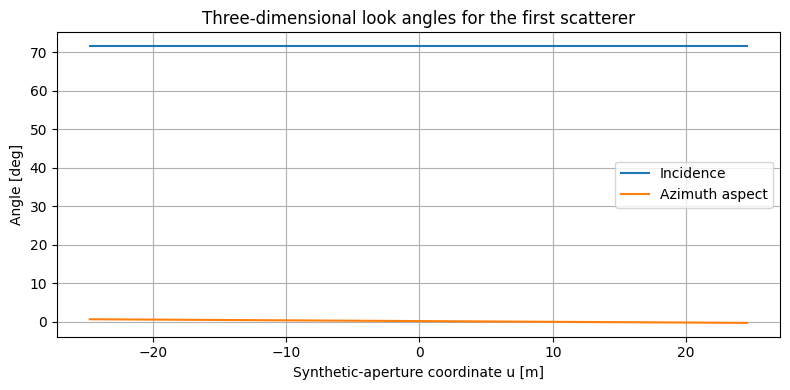

In [93]:
x_targets = np.array([-5.0])
y_targets = np.array([10.0])
rho_targets = np.array([1.0 + 3j], dtype=np.complex128)

def compute_look_geometry(x_target, y_target, params: SARParams):
    """Compute range, unit look vectors, incidence, and azimuth aspect."""
    axes = params.build_axes()
    u = axes["u"]

    radar = params.radar_position(u)
    target = params.target_positions(
        np.array([x_target]),
        np.array([y_target]),
    )[0]

    propagation = target[None, :] - radar
    R = np.linalg.norm(propagation, axis=1)
    k_inc = propagation / R[:, None]

    # Incidence angle measured from the downward vertical direction.
    incidence = np.arccos(np.clip(-k_inc[:, 2], -1.0, 1.0))

    # Horizontal aspect of the incident propagation vector.
    aspect = np.arctan2(k_inc[:, 1], k_inc[:, 0])

    return {
        "u": u,
        "radar": radar,
        "target": target,
        "R": R,
        "k_inc": k_inc,
        "incidence": incidence,
        "aspect": aspect,
    }


def plot_acquisition_geometry(
    x_targets,
    y_targets,
    params: SARParams,
):
    """Plot the flight trajectory, ground scene, and point scatterers in 3D."""
    axes = params.build_axes()
    u = axes["u"]

    radar = params.radar_position(u)
    targets = params.target_positions(x_targets, y_targets)

    X_grid, Y_grid = np.meshgrid(
        np.linspace(params.Xc - params.X0, params.Xc + params.X0, 2),
        np.linspace(-params.Y0, params.Y0, 2),
    )
    Z_grid = np.zeros_like(X_grid)

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(radar[:, 0], radar[:, 1], radar[:, 2], linewidth=2, label="Radar trajectory")
    ax.plot_surface(X_grid, Y_grid, Z_grid, alpha=0.18)
    ax.scatter(targets[:, 0], targets[:, 1], targets[:, 2], s=55, label="Ground scatterers")

    center_radar = params.radar_position(np.array([0.0]))[0]
    scene_center = np.array([params.Xc, 0.0, 0.0])
    ax.plot(
        [center_radar[0], scene_center[0]],
        [center_radar[1], scene_center[1]],
        [center_radar[2], scene_center[2]],
        linestyle="--",
        label="Central line of sight",
    )

    ax.set_xlabel("Ground range X [m]")
    ax.set_ylabel("Azimuth Y [m]")
    ax.set_zlabel("Altitude Z [m]")
    ax.set_title("Three-dimensional stripmap acquisition geometry")
    ax.legend()
    # Display aspect chosen for readability; axis values remain metric.
    ax.set_box_aspect((2.2, 1.0, 0.8))
    plt.tight_layout()
    plt.show()


def plot_look_angles(look):
    """Plot incidence and horizontal aspect along the synthetic aperture."""
    plt.figure(figsize=(8, 4))
    plt.plot(look["u"], np.degrees(look["incidence"]), label="Incidence")
    plt.plot(look["u"], np.degrees(look["aspect"]), label="Azimuth aspect")
    plt.xlabel("Synthetic-aperture coordinate u [m]")
    plt.ylabel("Angle [deg]")
    plt.title("Three-dimensional look angles for the first scatterer")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_acquisition_geometry(x_targets, y_targets, params)
look = compute_look_geometry(x_targets[0], y_targets[0], params)
plot_look_angles(look)


## 4. Raw SAR signal synthesis in 3D

For the $p$-th ground scatterer, the exact range history is
$$
R_p(u)=
\left\|
\mathbf r_p-\mathbf r_\mathrm{radar}(u)
\right\|
=
\sqrt{(X_c+x_p)^2+(y_p-u)^2+H^2}.
$$

The round-trip delay is

$$
\tau_p(u)=\frac{2R_p(u)}{c}.
$$

The complex baseband raw signal is synthesized as

$$
s(t,u)
=
\sum_p
\rho_p
\exp\left[
j\left(
-\omega_c\tau_p(u)
-\pi B t_d
+\alpha t_d^2
\right)
\right]
\mathbf 1_{0\leq t_d\leq T_p},
\qquad
t_d=t-\tau_p(u).
$$

At this stage, $\rho_p$ is still constant. Nevertheless, the function optionally passes the local frequency and three-dimensional look direction to a user-defined scattering law. This makes the transition to a non-white or anisotropic response explicit without changing the propagation model.


In [94]:
def synthesize_raw_sar_signal_3d(
    x_targets,
    y_targets,
    rho_targets,
    params: SARParams,
    batch_size: int = 32,
    dtype=np.complex128,
    include_range_attenuation: bool = False,
    scattering_law=None,
):
    """
    Synthesize the complex baseband raw signal for ground scatterers.

    Parameters
    ----------
    scattering_law : callable or None
        Optional function
            rho_eff = scattering_law(f_inst, k_inc, rho0)
        where f_inst has shape (n, nb, m), k_inc has shape (nb, m, 3),
        and rho0 has shape (nb,). The returned array must be broadcastable
        to (n, nb, m).
    """
    axes = params.build_axes()

    c = axes["c"]
    wc = axes["wc"]
    B = axes["B"]
    alpha = axes["alpha"]
    Tp = axes["Tp"]

    t = axes["t"]
    u = axes["u"]
    n = axes["n"]
    m = axes["m"]

    x_targets = np.asarray(x_targets, dtype=float)
    y_targets = np.asarray(y_targets, dtype=float)
    rho_targets = np.asarray(rho_targets, dtype=dtype)

    if not (len(x_targets) == len(y_targets) == len(rho_targets)):
        raise ValueError("x_targets, y_targets and rho_targets must have the same length.")

    if np.any(np.abs(x_targets) > params.X0):
        print("Warning: at least one target is outside the nominal ground-range extent.")
    if np.any(np.abs(y_targets) > params.Y0):
        print("Warning: at least one target is outside the nominal azimuth extent.")

    s = np.zeros((n, m), dtype=dtype)
    n_targets = len(rho_targets)

    radar = params.radar_position(u)

    for start in range(0, n_targets, batch_size):
        stop = min(start + batch_size, n_targets)

        xb = x_targets[start:stop]
        yb = y_targets[start:stop]
        rb = rho_targets[start:stop]

        targets = params.target_positions(xb, yb)

        # Vector from radar to target: shape (nb, m, 3).
        propagation = targets[:, None, :] - radar[None, :, :]
        R = np.linalg.norm(propagation, axis=2)
        k_inc = propagation / R[:, :, None]

        tau = 2.0 * R / c
        td = t[:, None, None] - tau[None, :, :]

        gate = (td >= 0.0) & (td <= Tp)

        phase = (
            -wc * tau[None, :, :]
            -np.pi * B * td
            +alpha * td**2
        )

        echo = np.exp(1j * phase) * gate

        if scattering_law is None:
            rho_eff = rb[None, :, None]
        else:
            # Instantaneous RF frequency of the linear chirp.
            f_inst = (
                params.fc
                - B / 2.0
                + (B / Tp) * td
            )
            rho_eff = scattering_law(
                f_inst,
                k_inc[None, :, :, :],
                rb[None, :, None],
            )

        echo = rho_eff * echo

        if include_range_attenuation:
            echo = echo / (R[None, :, :] ** 2)

        s += np.sum(echo, axis=1).astype(dtype)

    return s


s = synthesize_raw_sar_signal_3d(
    x_targets,
    y_targets,
    rho_targets,
    params,
    batch_size=1,
    include_range_attenuation=False,
)


### Raw-signal visualization

The magnitude still resembles a broad transmitted pulse. The informative part of the stripmap acquisition is mainly the phase history along $u$, now generated by the complete three-dimensional range.


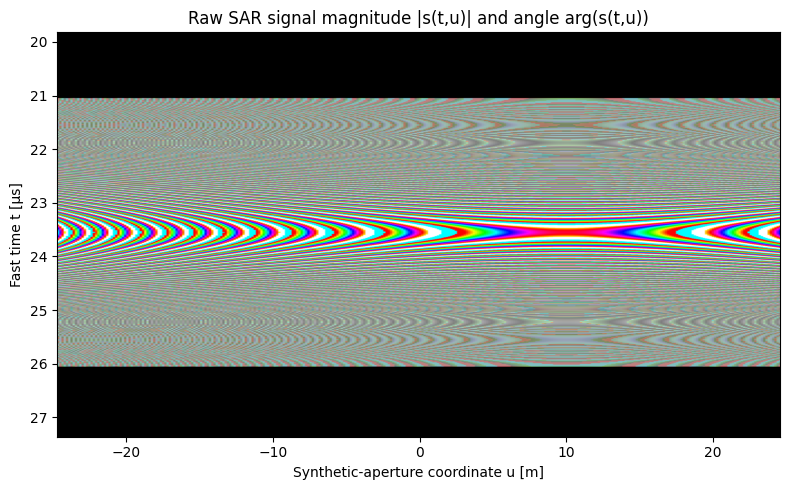

In [95]:
from matplotlib.colors import hsv_to_rgb
def plot_raw_signal_magnitude(s, params: SARParams, vmax=None) -> None:
    """Plot raw-signal magnitude in fast time and aperture coordinate."""
    axes = params.build_axes()
    t = axes["t"]
    u = axes["u"]

    amplitude = np.abs(s)
    arg=np.angle(s)

    if vmax is None:
        vmax = np.max(amplitude)

    amplitude=np.clip(amplitude, 0, vmax)/vmax
    rgb=hsv_to_rgb(np.stack([arg/np.pi+0.5, np.ones_like(arg), amplitude], axis=2)).clip(0,1)

    plt.figure(figsize=(8, 5))
    plt.imshow(
        rgb,
        extent=[u[0], u[-1], t[-1] * 1e6, t[0] * 1e6],
        aspect="auto",
    )
    plt.xlabel("Synthetic-aperture coordinate u [m]")
    plt.ylabel("Fast time t [µs]")
    plt.title("Raw SAR signal magnitude |s(t,u)| and angle arg(s(t,u))")
    plt.tight_layout()
    plt.show()



plot_raw_signal_magnitude(s, params)


## 5. Range filtering

The fast-time reference chirp is now computed for a ground point $(X_c+x_\mathrm{ref},0,0)$. Its zero-Doppler delay is therefore

$$
\tau_0=
\frac{2}{c}
\sqrt{(X_c+x_\mathrm{ref})^2+H^2}.
$$


In [96]:
def make_fast_time_reference(params: SARParams, x_ref: float = 0.0):
    """Build the fast-time reference chirp for a ground-range reference point."""
    axes = params.build_axes()

    c = axes["c"]
    wc = axes["wc"]
    B = axes["B"]
    alpha = axes["alpha"]
    Tp = axes["Tp"]
    t = axes["t"]

    X_ref = params.Xc + x_ref
    q_ref = float(params.ground_to_slant(X_ref))
    tau0 = 2.0 * q_ref / c
    td0 = t - tau0

    gate = (td0 >= 0.0) & (td0 <= Tp)

    phase = (
        -wc * tau0
        -np.pi * B * td0
        +alpha * td0**2
    )

    return np.exp(1j * phase) * gate


def fft_fast_time(x):
    """FFT along fast time with a centered output frequency grid."""
    return np.fft.fftshift(np.fft.fft(x, axis=0), axes=0)


def range_filter(
    s_raw,
    params: SARParams,
    x_ref: float = 0.0,
    mode: str = "whitened",
    eps: float = 1e-6,
):
    """Apply fast-time range filtering and retain the useful chirp band."""
    axes = params.build_axes()
    Ik = axes["Ik"]

    s0 = make_fast_time_reference(params, x_ref=x_ref)

    S_raw = fft_fast_time(s_raw)
    S0 = fft_fast_time(s0)

    if mode == "matched":
        H = np.conj(S0)
    elif mode == "whitened":
        power = np.abs(S0) ** 2
        H = np.conj(S0) / (power + eps * np.max(power))
    else:
        raise ValueError("mode must be either 'matched' or 'whitened'.")

    S_range = S_raw * H[:, None]
    S_range = S_range[Ik, :]

    return S_range, s0, S0, H


## 6. Fourier utilities and centered zero padding


In [97]:
def fft_aperture(u_signal):
    """FFT along the centered synthetic-aperture coordinate u."""
    return np.fft.fftshift(
        np.fft.fft(
            np.fft.ifftshift(u_signal, axes=1),
            axis=1,
        ),
        axes=1,
    )


def fft_aperture_padded(u_signal, m_fft: int):
    """FFT along aperture after centered zero padding."""
    nk, m = u_signal.shape

    if m_fft < m:
        raise ValueError("m_fft must be at least the number of aperture samples.")
    if m_fft % 2 != 0:
        raise ValueError("m_fft must be even.")

    padded = np.zeros((nk, m_fft), dtype=u_signal.dtype)
    start = (m_fft - m) // 2
    padded[:, start:start + m] = u_signal

    return np.fft.fftshift(
        np.fft.fft(
            np.fft.ifftshift(padded, axes=1),
            axis=1,
        ),
        axes=1,
    )


def ifft2_centered(F):
    """Centered two-dimensional inverse FFT."""
    return np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(F, axes=(0, 1)),
            axes=(0, 1),
        ),
        axes=(0, 1),
    )


def zero_pad_kq(F, pad_factor: int = 1):
    """Centered zero padding along the slant-range wavenumber dimension."""
    if pad_factor == 1:
        return F
    if pad_factor < 1:
        raise ValueError("pad_factor must be at least 1.")

    nq, ny = F.shape
    nq_pad = int(pad_factor * nq)
    if nq_pad % 2 != 0:
        nq_pad += 1

    F_pad = np.zeros((nq_pad, ny), dtype=F.dtype)
    start = (nq_pad - nq) // 2
    F_pad[start:start + nq, :] = F

    return F_pad


## 7. Omega–$k$ reconstruction in slant coordinates

Because

$$
R_p(u)=\sqrt{q_p^2+(y_p-u)^2},
$$

the usual monostatic dispersion relation remains valid:

$$
k_q=\sqrt{4k^2-k_y^2}.
$$

The important change is interpretative and geometric: $k_q$ is conjugate to the cross-track slant coordinate $q$, not to ground range $X$. The RMA first forms a uniformly sampled image $f(q,y)$. A second interpolation then evaluates this complex image at

$$
q(X)=\sqrt{X^2+H^2}
$$

on a uniform ground-range grid. This remapping preserves phase by interpolating the real and imaginary parts separately.


In [98]:
def remap_slant_image_to_ground(
    image_slant_complex,
    slant_axis,
    params: SARParams,
    ground_axis=None,
):
    """Remap a complex image from uniform slant range q to uniform ground range X."""
    image_slant_complex = np.asarray(image_slant_complex)
    slant_axis = np.asarray(slant_axis, dtype=float)

    if ground_axis is None:
        ground_axis = np.linspace(
            params.Xc - params.X0,
            params.Xc + params.X0,
            len(slant_axis),
        )
    else:
        ground_axis = np.asarray(ground_axis, dtype=float)

    q_query = params.ground_to_slant(ground_axis)

    image_ground = np.zeros(
        (image_slant_complex.shape[0], len(ground_axis)),
        dtype=np.complex128,
    )

    for iy in range(image_slant_complex.shape[0]):
        interp_real = interp1d(
            slant_axis,
            np.real(image_slant_complex[iy]),
            kind="linear",
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )
        interp_imag = interp1d(
            slant_axis,
            np.imag(image_slant_complex[iy]),
            kind="linear",
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )
        image_ground[iy] = interp_real(q_query) + 1j * interp_imag(q_query)

    return image_ground, ground_axis


def reconstruct_sar_ground_range_azimuth(
    s_raw,
    params: SARParams,
    interpolation_kind: str = "linear",
    x_ref: float = 0.0,
    window: Optional[str] = None,
    use_stolt_jacobian: bool = False,
    range_filter_mode: str = "whitened",
    range_zeropad: int = 8,
    y_output_extent: Optional[float] = None,
):
    """
    Reconstruct a ground-range/azimuth SAR image with a 3D acquisition geometry.

    The omega-k processing itself is performed in slant coordinates (q,y),
    followed by a complex interpolation from q to ground range X.
    """
    axes = params.build_axes()

    pi2 = axes["pi2"]
    k = axes["k"]
    Ik = axes["Ik"]

    n = axes["n"]
    m = axes["m"]

    du = axes["du"]
    ku = axes["ku"]
    dku = axes["dku"]

    Rc = axes["Rc"]
    q_half_extent = axes["q_half_extent"]

    s_raw = np.asarray(s_raw, dtype=np.complex128)

    if s_raw.shape != (n, m):
        raise ValueError(
            f"s_raw has shape {s_raw.shape}, but expected shape is {(n, m)}."
        )

    # Step 1: fast-time range filtering.
    S_range, s0, S0, H_range = range_filter(
        s_raw,
        params,
        x_ref=x_ref,
        mode=range_filter_mode,
    )

    k_valid = k[Ik]

    # Step 2: aperture FFT.
    if y_output_extent is None:
        S_ky = fft_aperture(S_range)
        ky = ku.copy()
        dky = dku
        ny = len(ky)
    else:
        m_fft_az = next_even_integer(y_output_extent / du)
        m_fft_az = max(m_fft_az, m)

        S_ky = fft_aperture_padded(S_range, m_fft=m_fft_az)

        ny = m_fft_az
        dky = pi2 / (ny * du)
        ky = (np.arange(ny) - ny / 2.0) * dky

    dy = pi2 / (ny * dky)
    azimuth_axis = (np.arange(ny) - ny / 2.0) * dy

    # Step 3: 3D geometry reduced to the (q,y) dispersion relation.
    kq_squared = 4.0 * k_valid[:, None] ** 2 - ky[None, :] ** 2
    valid_kq = kq_squared > 0.0

    kq = np.zeros_like(kq_squared)
    kq[valid_kq] = np.sqrt(kq_squared[valid_kq])

    # Step 4: phase compensation around the central slant range Rc.
    phase_filter = (
        kq * Rc
        + np.pi / 4.0
        - 2.0 * k_valid[:, None] * Rc
    )

    H_2d = np.exp(1j * phase_filter)
    H_2d *= valid_kq

    S_matched = S_ky * H_2d

    if use_stolt_jacobian:
        k_grid = np.repeat(k_valid[:, None], ny, axis=1)
        jacobian = np.zeros_like(kq)
        jacobian[valid_kq] = kq[valid_kq] / (4.0 * k_grid[valid_kq])
        S_matched *= jacobian

    # Step 5: Stolt interpolation onto a uniform kq grid.
    kq_positive = kq[valid_kq]
    kq_min = np.min(kq_positive)
    kq_max = np.max(kq_positive)

    dkq = np.pi / q_half_extent

    nq = int(np.floor((kq_max - kq_min) / dkq)) + 1
    nq = nq if nq % 2 == 0 else nq + 1

    KQ = kq_min + np.arange(nq) * dkq
    F = np.zeros((nq, ny), dtype=np.complex128)

    for j in range(ny):
        valid = valid_kq[:, j]

        if np.count_nonzero(valid) < 4:
            continue

        kq_j = kq[valid, j]
        S_j = S_matched[valid, j]

        order = np.argsort(kq_j)
        kq_j = kq_j[order]
        S_j = S_j[order]

        kq_unique, unique_idx = np.unique(kq_j, return_index=True)
        S_unique = S_j[unique_idx]

        if len(kq_unique) < 4:
            continue

        interp_real = interp1d(
            kq_unique,
            np.real(S_unique),
            kind=interpolation_kind,
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )
        interp_imag = interp1d(
            kq_unique,
            np.imag(S_unique),
            kind=interpolation_kind,
            bounds_error=False,
            fill_value=0.0,
            assume_sorted=True,
        )

        F[:, j] = interp_real(KQ) + 1j * interp_imag(KQ)

    # Step 6: optional spectral apodization.
    if window is not None:
        if window == "hann":
            wq = np.hanning(nq)
            wy = np.hanning(ny)
        elif window == "hamming":
            wq = np.hamming(nq)
            wy = np.hamming(ny)
        else:
            raise ValueError("window must be None, 'hann' or 'hamming'.")

        F = F * wq[:, None] * wy[None, :]

    # Step 7: inverse FFT in uniform slant coordinates.
    F_ifft = zero_pad_kq(F, pad_factor=range_zeropad)
    nq_ifft = F_ifft.shape[0]

    f_qy = ifft2_centered(F_ifft)

    dq = pi2 / (nq_ifft * dkq)
    q_relative = (np.arange(nq_ifft) - nq_ifft / 2.0) * dq
    slant_axis = Rc + q_relative

    # f_qy is indexed as f[q,y]; transpose to image[y,q].
    image_slant_complex = f_qy.T

    # Step 8: complex remapping to a uniform ground-range grid.
    image_ground_complex, ground_range_axis = remap_slant_image_to_ground(
        image_slant_complex,
        slant_axis,
        params,
    )
    image_ground = np.abs(image_ground_complex)

    debug = {
        "s0": s0,
        "S0": S0,
        "H_range": H_range,
        "S_range": S_range,
        "S_ky": S_ky,
        "k_valid": k_valid,
        "ky": ky,
        "kq": kq,
        "valid_kq": valid_kq,
        "H_2d": H_2d,
        "S_matched": S_matched,
        "KQ": KQ,
        "F_before_padding": F,
        "F_ifft": F_ifft,
        "f_qy": f_qy,
        "image_slant_complex": image_slant_complex,
        "image_ground_complex": image_ground_complex,
        "dq": dq,
        "dy": dy,
        "dkq": dkq,
        "dky": dky,
        "slant_axis": slant_axis,
        "ground_range_axis": ground_range_axis,
        "azimuth_axis": azimuth_axis,
        "range_filter_mode": range_filter_mode,
        "range_zeropad": range_zeropad,
    }

    return image_ground, ground_range_axis, azimuth_axis, debug


image, ground_range_axis, azimuth_axis, debug = reconstruct_sar_ground_range_azimuth(
    s,
    params,
    interpolation_kind="linear",
    window=None,
    use_stolt_jacobian=False,
    range_filter_mode="whitened",
    range_zeropad=8,
    y_output_extent=2.0 * params.Y0,
)

iy, ix = np.unravel_index(np.argmax(image), image.shape)

print("Reconstructed maximum:")
print(f"Ground range X = {ground_range_axis[ix]:.3f} m")
print(f"Azimuth Y      = {azimuth_axis[iy]:.3f} m")
print(f"Amplitude      = {image[iy, ix]:.6e}")


Reconstructed maximum:
Ground range X = 2994.961 m
Azimuth Y      = 9.924 m
Amplitude      = 2.517877e+00


## 8. Ground-range/azimuth visualization

The displayed horizontal coordinate is now the physical ground-range coordinate $X$, after complex slant-to-ground remapping.


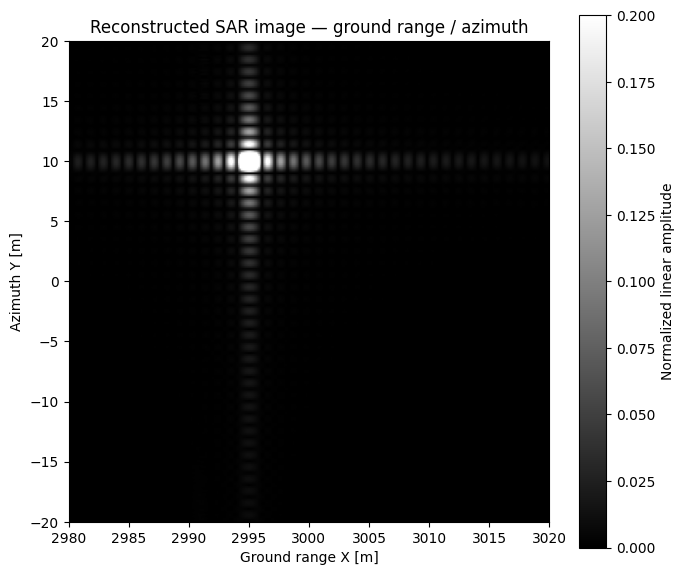

In [99]:
def plot_reconstructed_linear(
    image,
    ground_range_axis,
    azimuth_axis,
    params: Optional[SARParams] = None,
    vmax: float = 1.0,
    y_lim=None,
    x_lim=None,
    title: str = "Reconstructed SAR image — ground range / azimuth",
):
    """Plot a reconstructed SAR image on a normalized linear amplitude scale."""
    image_norm = image / (np.max(image) + 1e-15)

    plt.figure(figsize=(7, 6))
    plt.imshow(
        image_norm,
        extent=[
            ground_range_axis[0],
            ground_range_axis[-1],
            azimuth_axis[0],
            azimuth_axis[-1],
        ],
        origin="lower",
        aspect="equal",
        cmap="gray",
        vmin=0,
        vmax=vmax,
    )

    plt.xlabel("Ground range X [m]")
    plt.ylabel("Azimuth Y [m]")
    plt.title(title)
    plt.colorbar(label="Normalized linear amplitude")

    if x_lim is not None:
        plt.xlim(*x_lim)
    elif params is not None:
        plt.xlim(params.Xc - params.X0, params.Xc + params.X0)

    if y_lim is not None:
        plt.ylim(*y_lim)
    elif params is not None:
        plt.ylim(-params.Y0, params.Y0)

    plt.tight_layout()
    plt.show()


plot_reconstructed_linear(
    image,
    ground_range_axis,
    azimuth_axis,
    params=params,
    vmax=0.2,
    x_lim=(params.Xc - 20, params.Xc + 20),
    y_lim=(-20, 20),
)


## 9. Point-spread-function diagnostics

The PSF is now measured in physical ground-range and azimuth coordinates. Its ground-range width is expected to be slightly broader than the slant-range resolution by the factor \(1/\sin	heta_c\).


=== Reconstructed maximum ===
Ground range X = 2994.961 m
Azimuth Y      = 9.924 m

=== Full width at half maximum ===
Ground-range FWHM = 1.279 m
Azimuth FWHM      = 1.208 m


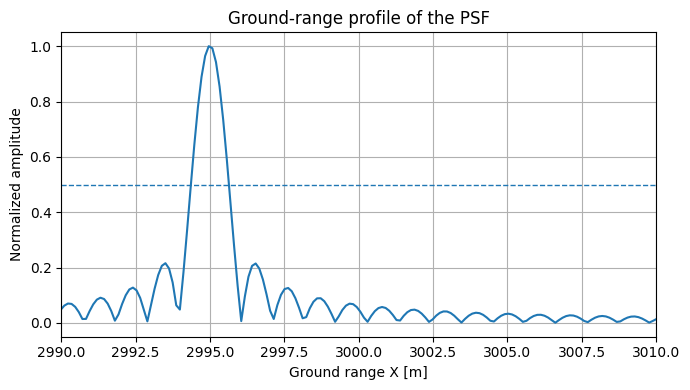

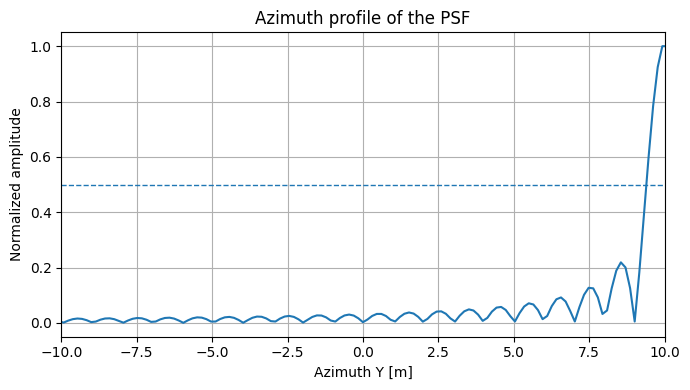

In [100]:
def estimate_fwhm(axis, profile):
    """Estimate the full width at half maximum of a positive 1D profile."""
    profile = np.asarray(profile, dtype=float)
    profile = profile / (np.max(profile) + 1e-15)

    peak_idx = np.argmax(profile)
    half = 0.5

    left = peak_idx
    while left > 0 and profile[left] >= half:
        left -= 1

    right = peak_idx
    while right < len(profile) - 1 and profile[right] >= half:
        right += 1

    if left == 0 or right == len(profile) - 1:
        return np.nan

    x1, x2 = axis[left], axis[left + 1]
    y1, y2 = profile[left], profile[left + 1]
    x_left = x1 + (half - y1) * (x2 - x1) / (y2 - y1 + 1e-15)

    x1, x2 = axis[right - 1], axis[right]
    y1, y2 = profile[right - 1], profile[right]
    x_right = x1 + (half - y1) * (x2 - x1) / (y2 - y1 + 1e-15)

    return x_right - x_left


def analyze_point_spread_function(image, ground_range_axis, azimuth_axis):
    """Extract ground-range and azimuth profiles through the image maximum."""
    image = np.abs(image)
    image = image / (np.max(image) + 1e-15)

    iy, ix = np.unravel_index(np.argmax(image), image.shape)

    ground_profile = image[iy, :]
    azimuth_profile = image[:, ix]

    fwhm_ground = estimate_fwhm(ground_range_axis, ground_profile)
    fwhm_azimuth = estimate_fwhm(azimuth_axis, azimuth_profile)

    print("=== Reconstructed maximum ===")
    print(f"Ground range X = {ground_range_axis[ix]:.3f} m")
    print(f"Azimuth Y      = {azimuth_axis[iy]:.3f} m")
    print()
    print("=== Full width at half maximum ===")
    print(f"Ground-range FWHM = {fwhm_ground:.3f} m")
    print(f"Azimuth FWHM      = {fwhm_azimuth:.3f} m")

    return {
        "ix": ix,
        "iy": iy,
        "ground_profile": ground_profile,
        "azimuth_profile": azimuth_profile,
        "fwhm_ground": fwhm_ground,
        "fwhm_azimuth": fwhm_azimuth,
    }


def plot_psf_profiles(psf, ground_range_axis, azimuth_axis, params=None):
    """Plot ground-range and azimuth profiles through the PSF maximum."""
    plt.figure(figsize=(7, 4))
    plt.plot(ground_range_axis, psf["ground_profile"])
    plt.axhline(0.5, linestyle="--", linewidth=1)
    if params is not None:
        plt.xlim(params.Xc - 10, params.Xc + 10)
    plt.xlabel("Ground range X [m]")
    plt.ylabel("Normalized amplitude")
    plt.title("Ground-range profile of the PSF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(azimuth_axis, psf["azimuth_profile"])
    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.xlim(-10, 10)
    plt.xlabel("Azimuth Y [m]")
    plt.ylabel("Normalized amplitude")
    plt.title("Azimuth profile of the PSF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


psf = analyze_point_spread_function(image, ground_range_axis, azimuth_axis)
plot_psf_profiles(psf, ground_range_axis, azimuth_axis, params=params)


## 10. Several ground scatterers

The same processing chain applies without changing the three-dimensional propagation geometry.


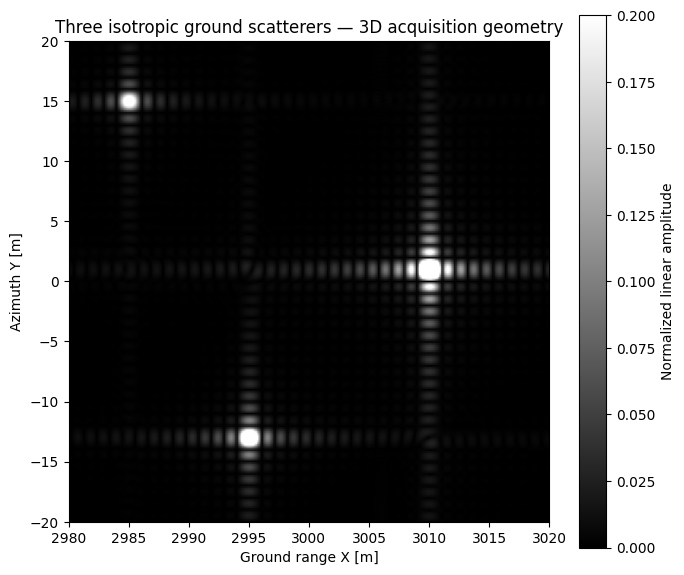

In [104]:
x_targets_multi = np.array([-15.0, 10.0, -5.0])
y_targets_multi = np.array([15.0, 1.0, -13.0])
rho_targets_multi = np.array(
    [1.0 + 0j, 2.0 + 3j, 1.2 + 1.2j],
    dtype=np.complex128,
)

s_multi = synthesize_raw_sar_signal_3d(
    x_targets_multi,
    y_targets_multi,
    rho_targets_multi,
    params,
    batch_size=3,
    include_range_attenuation=False,
)

image_multi, ground_axis_multi, azimuth_axis_multi, debug_multi = (
    reconstruct_sar_ground_range_azimuth(
        s_multi,
        params,
        interpolation_kind="linear",
        window=None,
        use_stolt_jacobian=False,
        range_filter_mode="whitened",
        range_zeropad=8,
        y_output_extent=2.0 * params.Y0,
    )
)

plot_reconstructed_linear(
    image_multi,
    ground_axis_multi,
    azimuth_axis_multi,
    params=params,
    vmax=0.2,
    x_lim=(params.Xc - 20, params.Xc + 20),
    y_lim=(-20, 20),
    title="Three isotropic ground scatterers — 3D acquisition geometry",
)


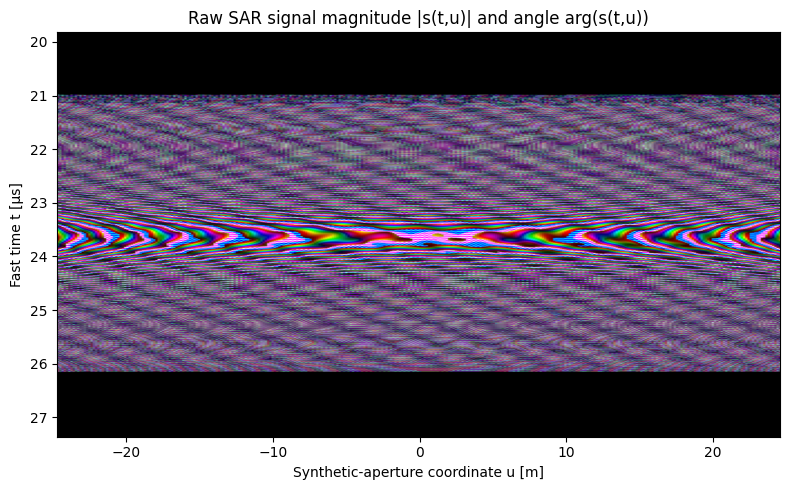

In [105]:
plot_raw_signal_magnitude(s_multi, params)